# Fast TinyLlama LoRA fine-tuning for `claims.jsonl` from Google Drive

This notebook is built for Google Colab and avoids the dependency problems caused by incompatible `torchvision`, `torchao`, and `bitsandbytes` installs.

Main design choices:

- data is loaded from `/content/drive/MyDrive`;
- training uses **LoRA**, not full-model fine-tuning;
- `torchvision` is removed because this is a text-only task;
- prompt tokens are masked with `-100`, so the model learns only the JSON answer;
- checkpoints are disabled during training to keep it fast.

## 1. Clean Colab dependencies

Run this cell first. It installs compatible Hugging Face packages and removes packages that caused the previous errors.

After installation, the runtime restarts automatically. After the restart, run this same cell again; it will skip installation and continue.

In [1]:
import os
import sys
import subprocess

DEPS_FLAG = "/content/.tinyllama_claims_lora_deps_v4"

if not os.path.exists(DEPS_FLAG):
    print("Installing clean dependencies...")

    commands = [
        [sys.executable, "-m", "pip", "uninstall", "-y", "torchvision", "torchaudio", "torchao", "bitsandbytes", "transformers", "peft", "accelerate"],
        [
            sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
            "pandas==2.2.2",
            "transformers==4.48.3",
            "peft==0.14.0",
            "accelerate==1.3.0",
            "datasets==3.6.0",
            "scikit-learn",
            "matplotlib",
        ],
    ]

    for cmd in commands:
        print("Running:", " ".join(cmd))
        subprocess.check_call(cmd)

    with open(DEPS_FLAG, "w") as f:
        f.write("installed")

    print("\nDependencies installed. Restarting runtime automatically...")
    os.kill(os.getpid(), 9)
else:
    print("Dependencies already installed. Continue to the next cell.")

Dependencies already installed. Continue to the next cell.


## 2. Imports and environment check

In [2]:
import os

# Keep this before importing transformers.
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json
import math
import inspect
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split

import transformers
import peft
import accelerate

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    set_seed,
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
)

print("torch:", torch.__version__)
print("torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("pandas:", pd.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("torchvision installed:", importlib.util.find_spec("torchvision") is not None)
print("bitsandbytes installed:", importlib.util.find_spec("bitsandbytes") is not None)
print("torchao installed:", importlib.util.find_spec("torchao") is not None)

if importlib.util.find_spec("torchvision") is not None:
    raise RuntimeError("torchvision is still installed. Re-run dependency cell and restart runtime.")
if importlib.util.find_spec("bitsandbytes") is not None:
    raise RuntimeError("bitsandbytes is still installed. Re-run dependency cell and restart runtime.")
if importlib.util.find_spec("torchao") is not None:
    raise RuntimeError("torchao is still installed. Re-run dependency cell and restart runtime.")

set_seed(42)

torch: 2.10.0+cu128
torch CUDA build: 12.8
CUDA available: True
pandas: 2.2.2
transformers: 4.48.3
peft: 0.14.0
accelerate: 1.3.0
torchvision installed: False
bitsandbytes installed: False
torchao installed: False


## 3. Mount Google Drive and find `claims.jsonl`

By default the notebook checks common locations in `MyDrive`. If needed, manually edit `MANUAL_DATA_PATH`.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")

# Set this manually if the auto-search finds the wrong file.
# Example: MANUAL_DATA_PATH = "/content/drive/MyDrive/my_project/data/claims.jsonl"
MANUAL_DATA_PATH = None

if MANUAL_DATA_PATH is not None:
    DATA_PATH = Path(MANUAL_DATA_PATH)
else:
    common_paths = [
        DRIVE_ROOT / "claims.jsonl",
        DRIVE_ROOT / "data" / "claims.jsonl",
        DRIVE_ROOT / "Colab Notebooks" / "claims.jsonl",
        DRIVE_ROOT / "Colab Notebooks" / "data" / "claims.jsonl",
    ]

    existing_common = [p for p in common_paths if p.exists()]

    if existing_common:
        DATA_PATH = existing_common[0]
    else:
        print("Searching MyDrive for claims.jsonl. This can take a little time if Drive is large...")
        matches = list(DRIVE_ROOT.rglob("claims.jsonl"))
        if not matches:
            raise FileNotFoundError(
                "Could not find claims.jsonl in MyDrive. Upload it to MyDrive or set MANUAL_DATA_PATH."
            )
        DATA_PATH = max(matches, key=lambda p: p.stat().st_mtime)

print("Using data file:", DATA_PATH)
print("File size MB:", round(DATA_PATH.stat().st_size / 1024 / 1024, 2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using data file: /content/drive/MyDrive/data/claims.jsonl
File size MB: 10.03


## 4. Configuration

In [4]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

OUTPUT_DIR = DRIVE_ROOT / "tinyllama_claims_lora_adapter"

# Good default for speed + quality on Colab GPUs.
MAX_LENGTH = 512
MAX_TARGET_LENGTH = 192
NUM_TRAIN_EPOCHS = 2
LEARNING_RATE = 2e-4


# Use this for debugging only. Keep as None for final training.
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None

SYSTEM_PROMPT = (
    "You are a claim extraction model. "
    "Extract clear, atomic, factual claims from the input text. "
    "Return only valid JSON with this exact schema: {\"claims\": [\"claim 1\", \"claim 2\"]}."
)

use_cuda = torch.cuda.is_available()
use_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
device = "cuda" if use_cuda else "mps" if use_mps else "cpu"

if use_cuda:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"Device: CUDA / {gpu_name} / {gpu_memory_gb:.1f} GB")
else:
    gpu_memory_gb = 0
    print("Device:", device)

print("Output dir:", OUTPUT_DIR)

Device: CUDA / Tesla T4 / 14.6 GB
Output dir: /content/drive/MyDrive/tinyllama_claims_lora_adapter


## 5. Load and normalise the dataset

Expected columns: `input` and `output`. The `output` column may be a dict, list, or string; it is normalised to valid JSON.

In [5]:
claims_df = pd.read_json(DATA_PATH, lines=True)

required_columns = {"input", "output"}
missing = required_columns - set(claims_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(claims_df.columns)}")

claims_df = claims_df.dropna(subset=["input", "output"]).copy()
claims_df["input"] = claims_df["input"].astype(str).str.strip()
claims_df = claims_df[claims_df["input"].str.len() > 0].reset_index(drop=True)


def normalise_output(output):
    if isinstance(output, dict):
        claims = output.get("claims", [])
    elif isinstance(output, list):
        claims = output
    elif pd.isna(output):
        claims = []
    else:
        text = str(output).strip()
        try:
            parsed = json.loads(text)
            if isinstance(parsed, dict):
                claims = parsed.get("claims", [])
            elif isinstance(parsed, list):
                claims = parsed
            else:
                claims = [text]
        except Exception:
            claims = [text]

    if not isinstance(claims, list):
        claims = [claims]

    clean_claims = []
    for claim in claims:
        claim = str(claim).strip()
        if claim:
            clean_claims.append(claim)

    return json.dumps({"claims": clean_claims}, ensure_ascii=False)


claims_df["target"] = claims_df["output"].apply(normalise_output)
claims_df = claims_df[claims_df["target"] != '{"claims": []}'].reset_index(drop=True)

print("Rows:", len(claims_df))
display(claims_df[["input", "target"]].head())

Rows: 5834


,input,target
0,Українська Центральна Рада (УЦР) — це перший у...,"{""claims"": [""Українська Центральна Рада (УЦР) ..."
1,Основні етапи діяльності Української Центральн...,"{""claims"": [""Українська Центральна Рада прогол..."
2,Українська Центральна Рада (УЦР) відіграла клю...,"{""claims"": [""Українська Центральна Рада (УЦР) ..."
3,"Основні документи, ухвалені Українською Центра...","{""claims"": [""Українська Центральна Рада ухвали..."
4,Універсальна Центральна Рада (УЦР) стикалася з...,"{""claims"": [""Універсальна Центральна Рада (УЦР..."


## 6. Train/validation split

In [8]:
MAX_TRAIN_SAMPLES = 1500
MAX_VAL_SAMPLES = 300

if len(claims_df) < MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES:
    raise ValueError(
        f"Dataset too small. Need at least {MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES} rows, "
        f"but got {len(claims_df)}."
    )

sampled_df = claims_df.sample(
    n=MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES,
    random_state=42,
).reset_index(drop=True)

train_df, val_df = train_test_split(
    sampled_df,
    train_size=MAX_TRAIN_SAMPLES,
    test_size=MAX_VAL_SAMPLES,
    random_state=42,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")

Training samples: 1,500
Validation samples: 300


## 7. Tokenizer and label masking

Important fix: labels for the prompt are `-100`, so the loss is computed only on the assistant JSON answer.

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"


def build_prompt(input_text: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": f"Input text:\n{input_text}\n\nExtract the claims.",
        },
    ]

    if tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

    return (
        f"System: {SYSTEM_PROMPT}\n"
        f"User: Input text:\n{input_text}\n\nExtract the claims.\n"
        "Assistant:"
    )


def tokenize_row(example):
    prompt = build_prompt(example["input"])
    target = example["target"] + tokenizer.eos_token

    prompt_budget = MAX_LENGTH - MAX_TARGET_LENGTH

    prompt_ids = tokenizer(
        prompt,
        add_special_tokens=False,
        truncation=True,
        max_length=prompt_budget,
    )["input_ids"]

    target_ids = tokenizer(
        target,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_TARGET_LENGTH,
    )["input_ids"]

    input_ids = prompt_ids + target_ids
    labels = [-100] * len(prompt_ids) + target_ids
    attention_mask = [1] * len(input_ids)

    input_ids = input_ids[:MAX_LENGTH]
    labels = labels[:MAX_LENGTH]
    attention_mask = attention_mask[:MAX_LENGTH]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


train_dataset = Dataset.from_pandas(train_df[["input", "target"]], preserve_index=False).map(
    tokenize_row,
    remove_columns=["input", "target"],
)

val_dataset = Dataset.from_pandas(val_df[["input", "target"]], preserve_index=False).map(
    tokenize_row,
    remove_columns=["input", "target"],
)


def count_label_tokens(dataset):
    return [sum(token_id != -100 for token_id in row["labels"]) for row in dataset]


train_label_counts = count_label_tokens(train_dataset)
val_label_counts = count_label_tokens(val_dataset)

print(f"Train label tokens: min={min(train_label_counts)}, mean={np.mean(train_label_counts):.1f}, max={max(train_label_counts)}")
print(f"Val label tokens:   min={min(val_label_counts)}, mean={np.mean(val_label_counts):.1f}, max={max(val_label_counts)}")

if min(train_label_counts) == 0 or min(val_label_counts) == 0:
    raise ValueError("Some samples have no target tokens. Increase MAX_TARGET_LENGTH.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Train label tokens: min=59, mean=157.1, max=192
Val label tokens:   min=45, mean=155.6, max=192


## 8. Custom collator

Do not use `DataCollatorForLanguageModeling` here, because it can overwrite the custom masked labels.

In [10]:
def claim_collator(features):
    max_len = max(len(feature["input_ids"]) for feature in features)

    if use_cuda:
        max_len = ((max_len + 7) // 8) * 8

    batch = {
        "input_ids": [],
        "attention_mask": [],
        "labels": [],
    }

    for feature in features:
        pad_len = max_len - len(feature["input_ids"])

        batch["input_ids"].append(
            feature["input_ids"] + [tokenizer.pad_token_id] * pad_len
        )
        batch["attention_mask"].append(
            feature["attention_mask"] + [0] * pad_len
        )
        batch["labels"].append(
            feature["labels"] + [-100] * pad_len
        )

    return {
        key: torch.tensor(value, dtype=torch.long)
        for key, value in batch.items()
    }

## 9. Load TinyLlama and add LoRA adapters

This intentionally uses normal LoRA, not 4-bit QLoRA, because the previous environment had broken `bitsandbytes`/`transformers` compatibility.

In [11]:
torch_dtype = (
    torch.bfloat16 if use_cuda and torch.cuda.is_bf16_supported()
    else torch.float16 if use_cuda
    else torch.float32
)

print("Loading base model with dtype:", torch_dtype)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    low_cpu_mem_usage=True,
)

model = model.to(device)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading base model with dtype: torch.bfloat16
trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


## 10. Training arguments

In [12]:
if use_cuda:
    if gpu_memory_gb >= 30:
        per_device_train_batch_size = 8
        gradient_accumulation_steps = 2
    elif gpu_memory_gb >= 14:
        per_device_train_batch_size = 4
        gradient_accumulation_steps = 4
    else:
        per_device_train_batch_size = 2
        gradient_accumulation_steps = 8
elif use_mps:
    per_device_train_batch_size = 1
    gradient_accumulation_steps = 8
else:
    per_device_train_batch_size = 1
    gradient_accumulation_steps = 16

bf16 = use_cuda and torch.cuda.is_bf16_supported()
fp16 = use_cuda and not bf16
optim = "adamw_torch_fused" if use_cuda else "adamw_torch"


def make_training_args(**kwargs):
    signature = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" not in signature and "eval_strategy" in kwargs:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    return TrainingArguments(**kwargs)


training_args = make_training_args(
    output_dir=str(OUTPUT_DIR),

    eval_strategy="epoch",

    save_strategy="no",

    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    num_train_epochs=NUM_TRAIN_EPOCHS,

    per_device_train_batch_size=per_device_train_batch_size,
    per_device_eval_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,

    weight_decay=0.0,
    max_grad_norm=1.0,

    logging_steps=20,
    prediction_loss_only=True,

    fp16=fp16,
    bf16=bf16,

    report_to="none",
    remove_unused_columns=False,

    dataloader_pin_memory=use_cuda,
    dataloader_num_workers=0,

    optim=optim,
)

print(f"per_device_train_batch_size={per_device_train_batch_size}")
print(f"gradient_accumulation_steps={gradient_accumulation_steps}")
print(f"effective_batch_size={per_device_train_batch_size * gradient_accumulation_steps}")
print(f"fp16={fp16}, bf16={bf16}, optim={optim}")

per_device_train_batch_size=4
gradient_accumulation_steps=4
effective_batch_size=16
fp16=False, bf16=True, optim=adamw_torch_fused


## 11. Train

In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=claim_collator,
)

train_result = trainer.train()
print(train_result)

eval_result = trainer.evaluate()
print(eval_result)

Epoch,Training Loss,Validation Loss
1,0.059300,0.092425


TrainOutput(global_step=186, training_loss=0.10598027081258836, metrics={'train_runtime': 4769.8139, 'train_samples_per_second': 0.629, 'train_steps_per_second': 0.039, 'total_flos': 7166577978114048.0, 'train_loss': 0.10598027081258836, 'epoch': 1.9813333333333332})


{'eval_loss': 0.09242476522922516, 'eval_runtime': 142.5731, 'eval_samples_per_second': 2.104, 'eval_steps_per_second': 0.526, 'epoch': 1.9813333333333332}


## 12. Save LoRA adapter to MyDrive

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Saved LoRA adapter and tokenizer to: {OUTPUT_DIR}")

Saved LoRA adapter and tokenizer to: /content/drive/MyDrive/tinyllama_claims_lora_adapter


## 13. Quick generation test

In [15]:
def extract_claims(text, max_new_tokens=192):
    model.eval()

    prompt = build_prompt(text)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_tokens = generated[0, inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


sample_text = val_df.iloc[0]["input"]

print("INPUT:")
print(sample_text[:1200])

print("\nPREDICTION:")
prediction = extract_claims(sample_text)
print(prediction)

print("\nTARGET:")
print(val_df.iloc[0]["target"])

try:
    parsed = json.loads(prediction)
    print("\nValid JSON: yes")
except Exception as exc:
    print("\nValid JSON: no")
    print("Reason:", exc)

INPUT:
У 1960-1970-х роках українська мова переживала певний ренесанс у культурному житті УРСР, зокрема в літературі, музиці та театрі. Проте, попри це, існували обмеження з боку радянської влади, що призводило до русифікації в освіті та медіа. Багато українських митців намагалися відстоювати права української мови, проте часто стикалися з репресіями.

PREDICTION:
{"claims": ["У 1960-1970-х роках українська мова переживала певний ренесанс у культурному житті УРСР.", "Українська мова переживала ренесанс у літературі.", "Українська мова переживала ренесанс у музиці.", "Українська мова переживала ренесанс у театрі.", "Проблеми з боку радянської влади призводили до русифікації в освіті.", "Проблеми з боку радянської влади призводили до русифікації в медіа.", "Багато українських митців намагалися відстоювати права української мови.", "Багато українських митців намагалися відсто

TARGET:
{"claims": ["У 1960-1970-х роках українська мова переживала певний ренесанс у культурному житті УРСР.", "

## 14. Optional: plot logged losses

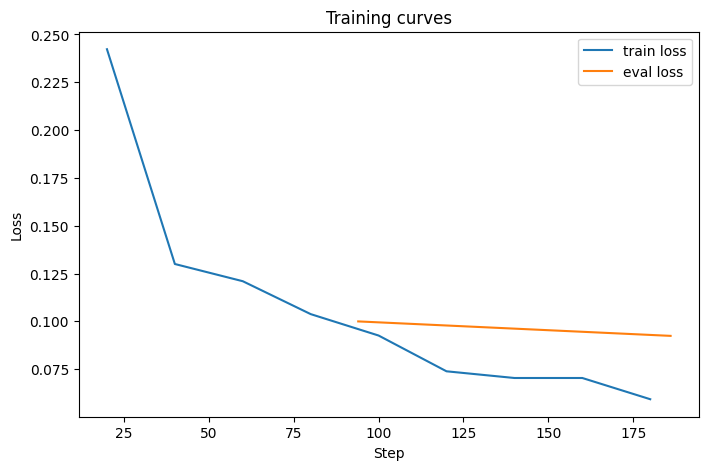

In [16]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
train_logs = [x for x in logs if "loss" in x]
eval_logs = [x for x in logs if "eval_loss" in x]

if train_logs:
    plt.figure(figsize=(8, 5))
    plt.plot([x["step"] for x in train_logs], [x["loss"] for x in train_logs], label="train loss")
    if eval_logs:
        plt.plot([x["step"] for x in eval_logs], [x["eval_loss"] for x in eval_logs], label="eval loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training curves")
    plt.legend()
    plt.show()
else:
    print("No loss logs found yet.")

In [17]:
FINAL_ADAPTER_DIR = OUTPUT_DIR / "final_adapter"

FINAL_ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

model.save_pretrained(FINAL_ADAPTER_DIR)
tokenizer.save_pretrained(FINAL_ADAPTER_DIR)

print(f"Saved final LoRA adapter to: {FINAL_ADAPTER_DIR}")

Saved final LoRA adapter to: /content/drive/MyDrive/tinyllama_claims_lora_adapter/final_adapter


In [19]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

adapter_files = list(MYDRIVE.rglob("adapter_config.json"))

print(f"Found {len(adapter_files)} LoRA adapter(s):")

for i, path in enumerate(adapter_files):
    print(f"{i}: {path.parent}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2 LoRA adapter(s):
0: /content/drive/MyDrive/tinyllama_claims_lora_adapter
1: /content/drive/MyDrive/tinyllama_claims_lora_adapter/final_adapter


In [20]:
ADAPTER_DIR = adapter_files[1].parent

print("Using adapter:", ADAPTER_DIR)
print("Exists:", ADAPTER_DIR.exists())
print("Files:")
for file in ADAPTER_DIR.iterdir():
    print("-", file.name)

Using adapter: /content/drive/MyDrive/tinyllama_claims_lora_adapter/final_adapter
Exists: True
Files:
- README.md
- adapter_model.safetensors
- adapter_config.json
- tokenizer_config.json
- special_tokens_map.json
- tokenizer.model
- tokenizer.json


In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

tokenizer = AutoTokenizer.from_pretrained(str(ADAPTER_DIR), use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    low_cpu_mem_usage=True,
)

model = PeftModel.from_pretrained(
    base_model,
    str(ADAPTER_DIR),
)

model = model.to(device)
model.eval()

print("Loaded trained LoRA adapter from:", ADAPTER_DIR)

Loaded trained LoRA adapter from: /content/drive/MyDrive/tinyllama_claims_lora_adapter/final_adapter


In [23]:
def extract_claims(text, max_new_tokens=160):
    prompt = build_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_tokens = generated[0, inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


text = """
Деякі історики та політики вважають Леніна «основоположником української державності», відзначаючи його роль у формуванні кордонів УРСР та підтримці національних республік у складі СРСР."""

print(extract_claims(text))

{"claims": ["Деякі історики та політики вважають Леніна «основоположником української державності».", "Деякі історики та політики відзначають роль Леніна у формуванні кордонів УРСР.", "Деякі історики та політики відзначають роль Леніна у підтримці національних республік у складі СРСР."]}
